# Create SWOT image with different filter/ differentiation

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da

import matplotlib.pyplot as plt

import os
from glob import glob
from swot import browse_swot_250m, browse_swot_2km, add_grid_metrics,rotate_ggd
from cstes import swot_dir_2km, zarr_dir
from altimetry_filter import filter_diff_one, _concat, compute_filter_diff

In [2]:
pass_=16

# stencil
method = 'diff_only'
ds = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_{product}_{method}.nc'))
        

# Gaussian
method = 'gaussian'
cutoff = 5e3
dsg = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot',product, method, f'pass{pass_}_{product}_{method}_{int(cutoff)}.nc'))

# Fitting kernel
method = 'fitting_kernel'
npts = 13
dsk = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_{product}_{method}_{int(npts)}.nc'))


NameError: name 'product' is not defined

(array([5.0000e+00, 1.1000e+01, 5.0000e+00, 4.0000e+00, 7.0000e+00,
        3.0000e+00, 1.0000e+01, 1.0000e+01, 7.0000e+00, 2.3000e+01,
        2.3000e+01, 2.7000e+01, 4.5000e+01, 6.3000e+01, 9.6000e+01,
        9.7000e+01, 1.0100e+02, 1.3700e+02, 1.3100e+02, 1.7500e+02,
        1.5900e+02, 1.8800e+02, 1.9400e+02, 2.2900e+02, 2.8300e+02,
        3.1100e+02, 3.5200e+02, 4.7200e+02, 5.8400e+02, 7.6400e+02,
        1.0240e+03, 1.3580e+03, 1.7910e+03, 2.2700e+03, 2.8860e+03,
        3.7090e+03, 5.0870e+03, 6.8490e+03, 8.9540e+03, 1.1626e+04,
        1.5140e+04, 1.9664e+04, 2.4254e+04, 3.0074e+04, 3.5098e+04,
        4.0477e+04, 4.5362e+04, 4.9346e+04, 5.2605e+04, 5.5753e+04,
        5.3939e+04, 5.0880e+04, 4.7387e+04, 4.2086e+04, 3.5876e+04,
        3.0357e+04, 2.5653e+04, 2.1652e+04, 1.7956e+04, 1.4491e+04,
        1.2065e+04, 9.8390e+03, 7.8600e+03, 6.1830e+03, 4.8270e+03,
        3.9290e+03, 3.0280e+03, 2.3340e+03, 1.8550e+03, 1.4980e+03,
        1.2780e+03, 8.9300e+02, 7.2200e+02, 5.58

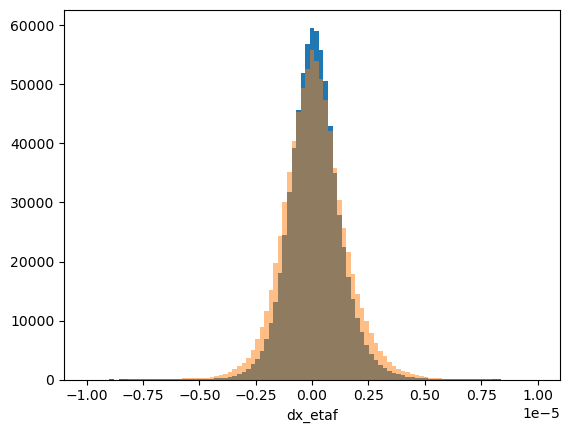

In [21]:
ds.dx_etaf.plot.hist(bins = np.linspace(-1e-5, 1e-5, 100))
dsk.dx_etaf.plot.hist(bins = np.linspace(-1e-5, 1e-5, 100), alpha=0.5)

(array([  633.,   650.,   669.,   742.,   801.,   741.,   755.,   828.,
          875.,   923.,   995.,   982.,  1030.,  1083.,  1150.,  1137.,
         1167.,  1252.,  1400.,  1474.,  1387.,  1642.,  1605.,  1741.,
         1813.,  1902.,  2035.,  2143.,  2237.,  2570.,  2616.,  2775.,
         2864.,  3154.,  3390.,  3603.,  3927.,  4176.,  4580.,  4851.,
         5335.,  5707.,  6362.,  6809.,  7479.,  8318.,  9009.,  9836.,
        10704., 11774., 12995., 13978., 15093., 16179., 17260., 17967.,
        18554., 19277., 18975., 18520., 17702., 17018., 15787., 14521.,
        13398., 12156., 11125., 10137.,  9415.,  8427.,  7694.,  7034.,
         6611.,  5899.,  5487.,  5026.,  4554.,  4281.,  4061.,  3660.,
         3369.,  3234.,  3094.,  2788.,  2598.,  2470.,  2361.,  2127.,
         2030.,  1903.,  1858.,  1709.,  1675.,  1493.,  1466.,  1433.,
         1369.,  1340.,  1283.]),
 array([-3.        , -2.93939394, -2.87878788, -2.81818182, -2.75757576,
        -2.6969697 , -2.63636

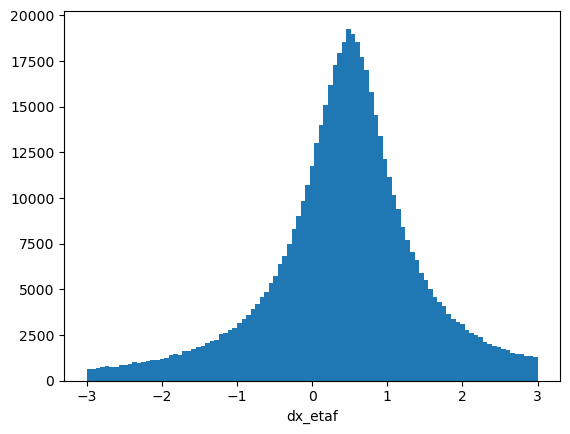

In [22]:
((ds.dx_etaf)/(dsk.dx_etaf)).plot.hist(bins = np.linspace(-3, 3, 100))

In [23]:
((ds.dx_etaf)/(dsk.dx_etaf)).mean()

<xarray.DataArray 'dx_etaf' ()> Size: 8B
array(0.99356595)

______________
# Functions

In [2]:
dfs = browse_swot_2km().reset_index()
df3 = dfs[dfs.pass_number==3]
df16 = dfs[dfs.pass_number==16]
ds3 = df3.set_index('cycle_number').to_xarray()
ds16 = df16.set_index('cycle_number').to_xarray()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [3]:
from altimetry_filter import filter_diff_one

def _concat(ds, filter_diff_method, filter_diff_kwargs):
    D = []
    for f in ds.file.values :
        D.append(filter_diff_one(f, filter_diff_method , filter_diff_kwargs))
    try : 
        xs = xr.concat(D, dim=ds.cycle_number)
    except : 
        assert False, f
    return xs

def compute_filter_diff(ds, filter_diff_method, filter_diff_kwargs):

    template = _concat(ds.isel(cycle_number = slice(0,2)), filter_diff_method ='gaussian', filter_diff_kwargs={'cutoff':5e3}).compute()
    template = template.isel(cycle_number=0).expand_dims({'cycle_number':ds.cycle_number}).chunk({**ds.chunks, **{'num_pixels':-1, 'num_lines':-1}})
    dims = [ "cycle_number", "num_lines", "num_pixels"]
    template = template.transpose(*dims)

    # actually perform the calculation
    ds_diff = ds.map_blocks(
        _concat,
        kwargs = dict( filter_diff_method =filter_diff_method, filter_diff_kwargs=filter_diff_kwargs),
        template=template,
    )
    return ds_diff

In [5]:
ds16 = df16[(df16.cycle_number!=534)&(df16.cycle_number!=513)&(df16.cycle_number!=554) &(df16.cycle_number!=568)].set_index('cycle_number').to_xarray()

In [6]:
# Test
ds = ds16.chunk({'cycle_number':2}).persist()
# Test compute_filter_diff
C = compute_filter_diff(ds, filter_diff_method = 'gaussian', filter_diff_kwargs={'cutoff':20e3}).compute()
C

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


ValueError: Result from applying user function does not contain data variables {'filtered_etaf', 'filtered_etac'}.

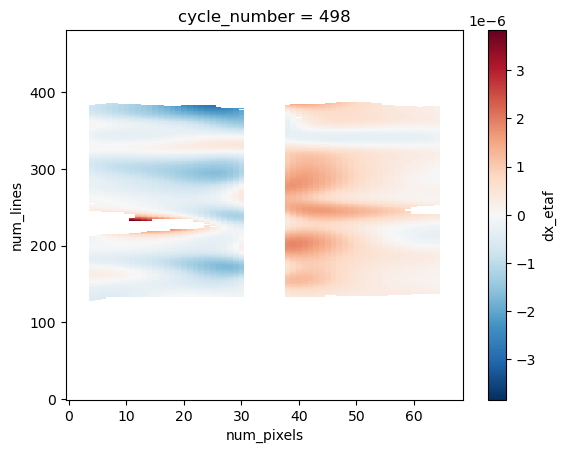

In [13]:
C.isel(cycle_number=19).dx_etaf.plot()

__________________
# 2km- Gaussian

In [19]:
product = 'swot2km'
method = 'gaussian'

if product == 'swot2km':
    dfs = browse_swot_2km().reset_index()

# Gaussian 
from cstes import zarr_dir
for pass_ in [3, 16] :
    df = dfs[dfs.pass_number==pass_]
    ds_swot = df.set_index('cycle_number').to_xarray().persist()
    for cutoff in np.arange(5e3, 60e3, 5e3) :
        C = compute_filter_diff(ds_swot, filter_diff_method = method, filter_diff_kwargs={'cutoff':cutoff}, mean_sla=True).compute()
        C['pass_number'] = pass_
        C['cutoff'] = cutoff
        C.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot',product, method, f'pass{pass_}_{product}_{method}_{int(cutoff)}.nc'))
        print(cutoff)

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

5000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

10000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

...

45000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

50000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

55000.0


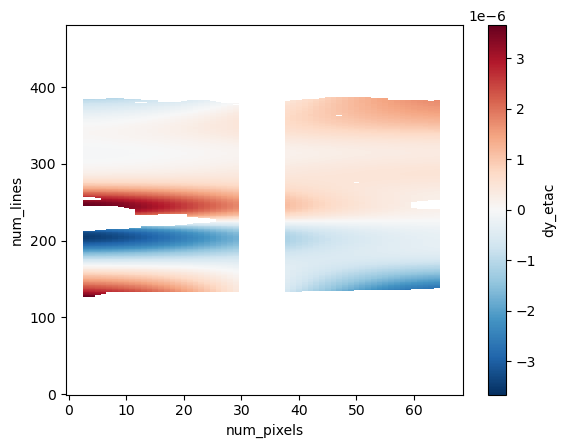

In [8]:
ds = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot',product, 'gaussian', f'pass{pass_}_{product}_{method}_{int(cutoff)}.nc'))
(ds.isel(cycle_number= 90)-ds.isel(cycle_number= 80)).dy_etac.plot()

In [7]:
os.path.join(zarr_dir, 'before_coloc','preprocessed_swot')

'/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot'

__________________
# 2km- Diff_only

In [2]:
product = 'swot2km'
method = 'diff_only'

if product == 'swot2km':
    dfs = browse_swot_2km().reset_index()
    
from cstes import zarr_dir
for pass_ in [3, 16] :
    df = dfs[dfs.pass_number==pass_]
    ds_swot = df.set_index('cycle_number').to_xarray()
    C = compute_filter_diff(ds_swot, filter_diff_method = method, filter_diff_kwargs={}, mean_sla=True).compute()
    C['pass_number'] = pass_
    C.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_{product}_{method}.nc'))
        

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


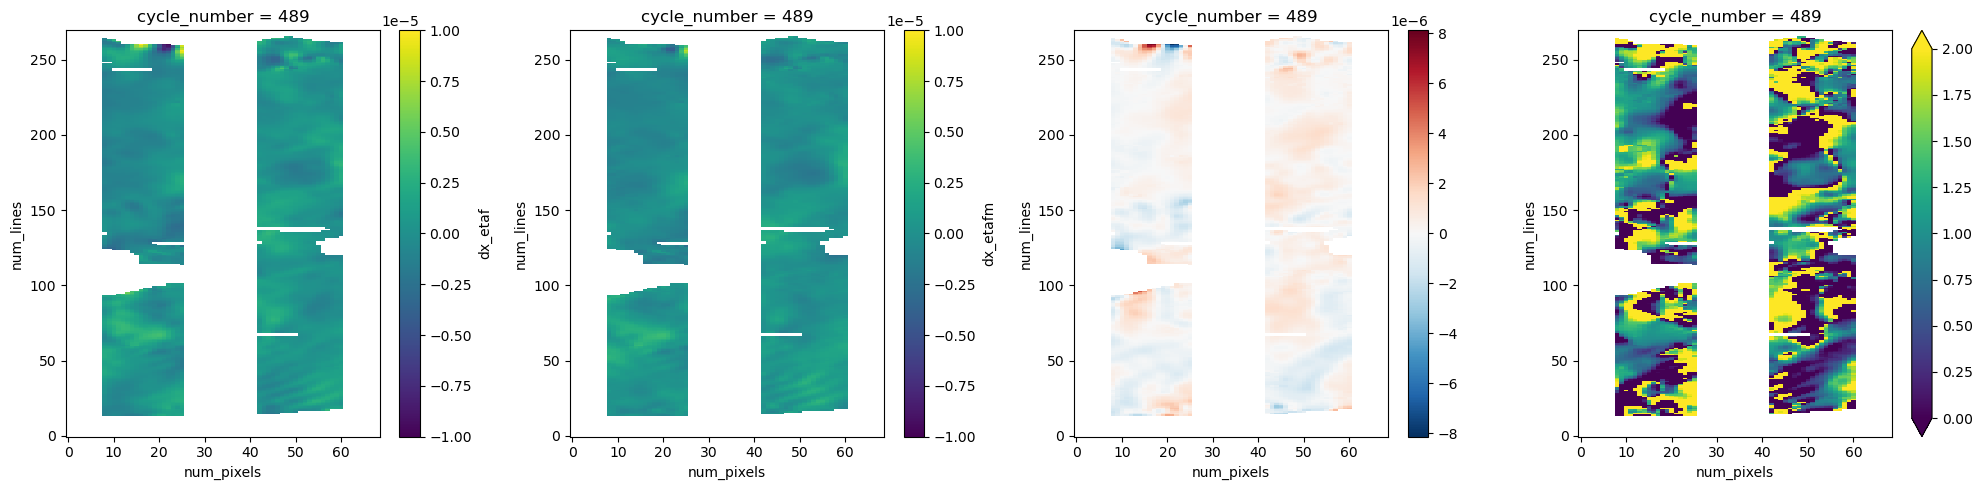

In [18]:
vmin, vmax = -1e-5, 1e-5
fig, axs = plt.subplots(1,4, figsize=(20, 5))
C.isel(cycle_number=10).dx_etaf.sel(num_lines = slice(120, 390)).plot(ax= axs[0], vmin=vmin, vmax=vmax, label = 'dx_etaf')
C.isel(cycle_number=10).dx_etafm.sel(num_lines = slice(120, 390)).plot(ax= axs[1], vmin=vmin, vmax=vmax, label = 'dx_etaf - mean sla')
(C.dx_etaf -C.dx_etafm).isel(cycle_number=10).sel(num_lines = slice(120, 390)).plot(ax= axs[2])
(C.dx_etaf /C.dx_etafm).isel(cycle_number=10).sel(num_lines = slice(120, 390)).plot(ax= axs[3], vmin=0, vmax=2)
fig.tight_layout()

__________________
# 2km- xarray diff

In [8]:
product = 'swot2km'
method = 'xarray_diff'

if product == 'swot2km':
    dfs = browse_swot_2km().reset_index()
    
from cstes import zarr_dir
for pass_ in [3, 16] :
    df = dfs[dfs.pass_number==pass_]
    ds_swot = df.set_index('cycle_number').to_xarray()
    C = compute_filter_diff(ds_swot, filter_diff_method = method, filter_diff_kwargs={}).compute()
    C['pass_number'] = pass_
    C.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_{product}_{method}.nc'))
        

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

_____________
# 2km-Fitting Kernel

In [ ]:
product = 'swot2km'
method = 'fitting_kernel'
if product == 'swot2km':
    dfs = browse_swot_2km().reset_index()

# Fitting kernel
from cstes import zarr_dir
for pass_ in [3, 16] :
    df = dfs[dfs.pass_number==pass_]
    ds_swot = df.set_index('cycle_number').to_xarray().chunk({'cycle_number':1}).persist()
    for npts in np.arange(5, 19, 2) :
        C = compute_filter_diff(ds_swot, filter_diff_method = method, filter_diff_kwargs={'npts':npts}).compute()
        C['pass_number'] = pass_
        C['npts'] = npts
        C.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_{product}_{method}_{int(npts)}.nc'))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

___________
# Other general variables (that will be only interpolated, not diff)

In [3]:

def preprocess(ds):
    ds = add_grid_metrics(ds)
    c = ds.cycle_number.mean().values
    ds = ds.assign_coords({"cycle_number": ("cycle_number", [c])})
    return ds[variables]

variables = ['ancillary_surface_classification_flag',
             'cross_track_distance',
             'distance_to_coast',
             'duacs_editing_flag',
             'duacs_phase_screen',
             'duacs_phase_screen_orbit',
             'duacs_phase_screen_static',
             'duacs_relative_vorticity',
             'duacs_speed_meridional',
             'duacs_speed_meridional_abs',
             'duacs_speed_zonal',
             'duacs_speed_zonal_abs',
             'duacs_strain',
             'duacs_xcal',
             'sig0_karin_2',
             'phi',
             'swh_model', 
             'ssh_karin_uncert',
             'cycle_number'
            ]

In [4]:
# Drifters
dsg = {}
product = 'swot2km'
# Alti general
if product == 'swot2km':
    dfs = browse_swot_2km().reset_index()
    df3 = dfs[dfs.pass_number==3]
    df16 = dfs[dfs.pass_number==16]
    dsg[3] = xr.open_mfdataset(df3.file.unique(), preprocess=preprocess, concat_dim='cycle_number', combine='nested')
    dsg[16] = xr.open_mfdataset(df16.file.unique(), preprocess=preprocess, concat_dim='cycle_number', combine='nested')

for pass_ in [3, 16]:
    ds = dsg[pass_]
    ds['pass_number'] = pass_
    ds.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'general', f'pass{pass_}_{product}_general.nc'))


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

NameError: name 'zarr_dir' is not defined

In [6]:
for pass_ in [3, 16]:
    ds = dsg[pass_]
    ds['pass_number'] = pass_
    ds.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'general', f'pass{pass_}_{product}_general.nc'))


In [42]:
method = 'fitting_kernel'
product = 'swot2km'
f = glob(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_*_swot2km_{method}.nc'))

In [11]:
dsg[3]

<xarray.Dataset> Size: 389MB
Dimensions:                                (cycle_number: 94, num_lines: 496,
                                            num_pixels: 69)
Coordinates:
    phi                                    (num_lines, num_pixels) float64 274kB dask.array<chunksize=(496, 69), meta=np.ndarray>
  * cycle_number                           (cycle_number) float64 752B 478.0 ...
    latitude                               (num_lines, num_pixels) float64 274kB dask.array<chunksize=(496, 69), meta=np.ndarray>
    latitude_nadir                         (cycle_number, num_lines) float64 373kB dask.array<chunksize=(1, 496), meta=np.ndarray>
    longitude                              (num_lines, num_pixels) float64 274kB dask.array<chunksize=(496, 69), meta=np.ndarray>
    longitude_nadir                        (cycle_number, num_lines) float64 373kB dask.array<chunksize=(1, 496), meta=np.ndarray>
    time                                   (cycle_number, num_lines) datetime64[ns] 373kB dask.array<chunksize=(1, 496), meta=np.ndarray>
    dx                                     (num_lines, num_pixels) float64 274kB dask.array<chunksize=(496, 69), meta=np.ndarray>
    dy                                     (num_lines, num_pixels) float64 274kB dask.array<chunksize=(496, 69), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/18)
    ancillary_surface_classification_flag  (cycle_number, num_lines, num_pixels) float32 13MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    cross_track_distance                   (cycle_number, num_lines, num_pixels) float32 13MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    distance_to_coast                      (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    duacs_editing_flag                     (cycle_number, num_lines, num_pixels) float32 13MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    duacs_phase_screen                     (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    duacs_phase_screen_orbit               (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    ...                                     ...
    duacs_strain                           (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    duacs_xcal                             (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    sig0_karin_2                           (cycle_number, num_lines, num_pixels) float32 13MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    swh_model                              (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    ssh_karin_uncert                       (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    pass_number                            int64 8B 3
Attributes:
    latc:     39.961324
    lonc:     4.3749
    phi:      76.80931729750104

In [9]:
ds1 = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'general', f'pass{pass_}_{product}_general.nc'))

In [10]:
ds1

<xarray.Dataset> Size: 365MB
Dimensions:                                (cycle_number: 91, num_lines: 481,
                                            num_pixels: 69)
Coordinates:
    phi                                    (num_lines, num_pixels) float64 266kB ...
  * cycle_number                           (cycle_number) float64 728B 478.0 ...
    latitude                               (num_lines, num_pixels) float64 266kB ...
    latitude_nadir                         (cycle_number, num_lines) float64 350kB ...
    longitude                              (num_lines, num_pixels) float64 266kB ...
    longitude_nadir                        (cycle_number, num_lines) float64 350kB ...
    time                                   (cycle_number, num_lines) datetime64[ns] 350kB ...
    dx                                     (num_lines, num_pixels) float64 266kB ...
    dy                                     (num_lines, num_pixels) float64 266kB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/18)
    ancillary_surface_classification_flag  (cycle_number, num_lines, num_pixels) float32 12MB ...
    cross_track_distance                   (cycle_number, num_lines, num_pixels) float32 12MB ...
    distance_to_coast                      (cycle_number, num_lines, num_pixels) float64 24MB ...
    duacs_editing_flag                     (cycle_number, num_lines, num_pixels) float32 12MB ...
    duacs_phase_screen                     (cycle_number, num_lines, num_pixels) float64 24MB ...
    duacs_phase_screen_orbit               (cycle_number, num_lines, num_pixels) float64 24MB ...
    ...                                     ...
    duacs_strain                           (cycle_number, num_lines, num_pixels) float64 24MB ...
    duacs_xcal                             (cycle_number, num_lines, num_pixels) float64 24MB ...
    sig0_karin_2                           (cycle_number, num_lines, num_pixels) float32 12MB ...
    swh_model                              (cycle_number, num_lines, num_pixels) float64 24MB ...
    ssh_karin_uncert                       (cycle_number, num_lines, num_pixels) float64 24MB ...
    pass_number                            int64 8B ...
Attributes:
    latc:     39.961324
    lonc:     4.3749
    phi:      76.80931729750104